# Building a Transformer Layer by Layer

A decoder transformer is assembled here one piece at a time: the attention
core, the projections around it, the residual wrapper, the feed-forward layer,
the repeated stack, and the embedding and output head at the two ends. The
finished expression is exported to JSON, given integer axis sizes and compiled
to a PyTorch module that runs on token indices.

*Written by Claude Opus 5 (1M context) at reasoning effort high, 2026-09-20.*

In [1]:
import json

import construction_helpers as ch  # noqa: F401 - operator overloads
import data_structure.Category as cat
import data_structure.Operators as ops
import data_structure.Term as fd
import data_transfer.term_json as term_json
import term_utilities.generate_config as generate_config
import torch
import torch_compile.torch_compile as torch_compile

import notebooks.display.notebook_diagrams as notebook_diagrams

DIAGRAMS = notebook_diagrams.DiagramSettings(
    mode=notebook_diagrams.DiagramMode.INLINE, width=900)

## The attention core

The scores contract the head dimension `k` of the queries against that of the
keys, the softmax runs over the keys, the mask keeps each query to the
positions at or before it, and the second contraction sums the values. The four
operations are grouped in one titled block.

The attention core. The mask stands between the softmax and the contraction against the values.


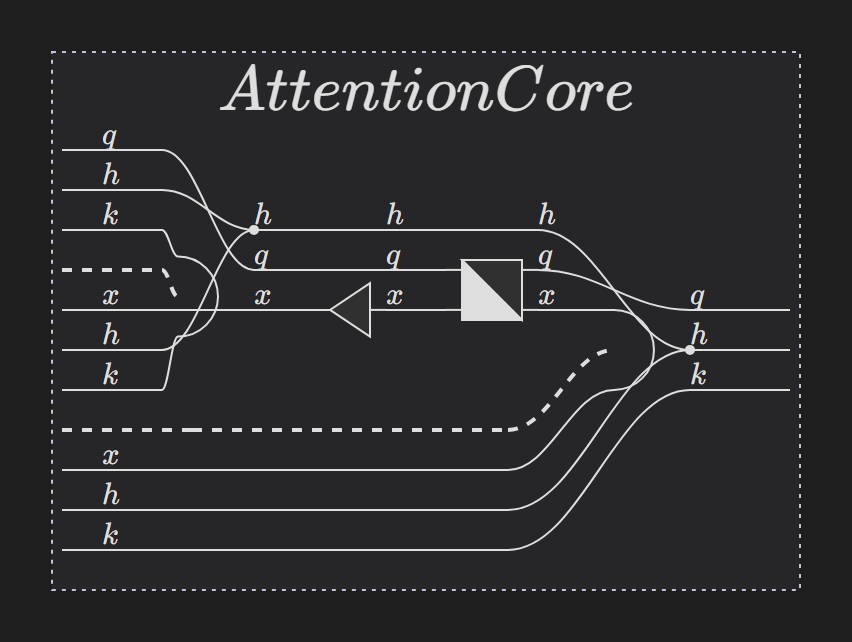

In [2]:
attention_core = cat.Block.template(
    ops.Einops.template('q h k, x h k -> h q x')
    @ ops.SoftMax.template()
    @ ops.WeightedTriangularLower.template()
    @ ops.Einops.template('h q x, x h k -> q h k'),
    title='Attention Core',
    fill_color='#C5BEDF')

assert len(attention_core.dom()) == 3, (
    'the core reads the queries, the keys and the values')
await notebook_diagrams.show_diagram(
    attention_core,
    'The attention core. The mask stands between the softmax and the contraction '
    'against the values.',
    settings=DIAGRAMS)

## The projections around the core

Each of the three projections reads the residual width `m` and writes two axes,
the heads and the head dimension. An integer output size mints that many fresh
axes, and composition names them from the contraction that consumes them. The
output projection reads the two axes back into `m`.

Multi-head attention. The three projections feed the core and the output projection reads the heads back into the residual width.


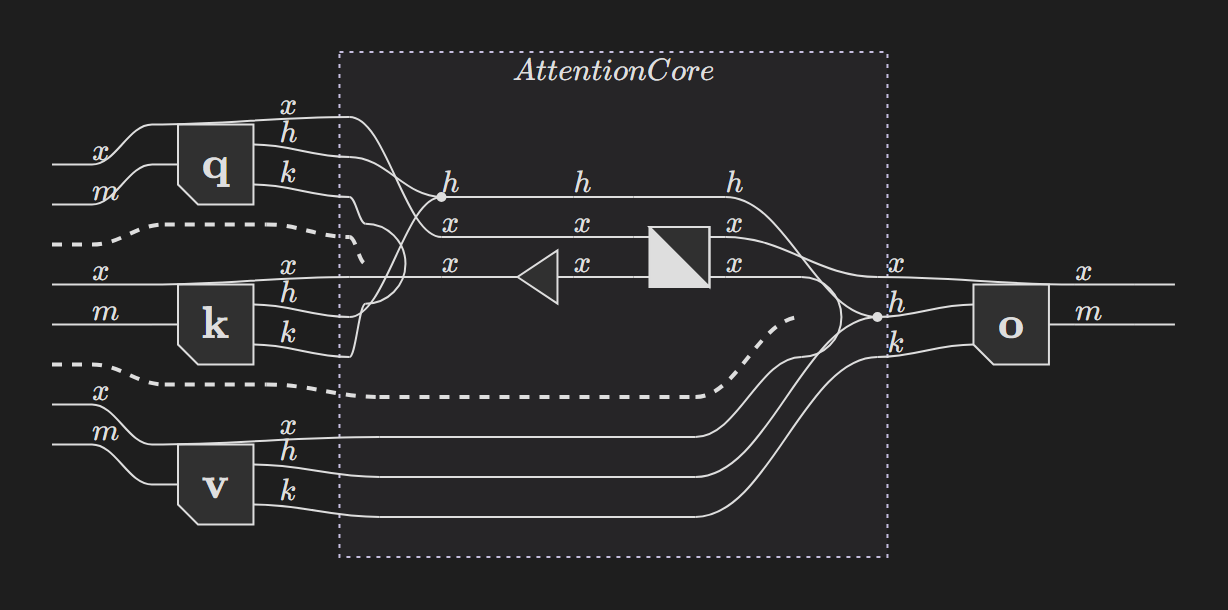

In [3]:
query_projection = ops.Linear.template(('m',), 2, 'q')
key_projection = ops.Linear.template(('m',), 2, 'k')
value_projection = ops.Linear.template(('m',), 2, 'v')
output_projection = ops.Linear.template(2, ('m',), 'o')
attention_layer = ((query_projection * key_projection * value_projection)
                   @ attention_core
                   @ output_projection)

assert [len(array.shape()) for array in attention_layer.dom()] == [2, 2, 2], (
    'the layer reads three arrays of tokens by residual width')
assert len(attention_layer.cod()[0].shape()) == 2, (
    'it writes one array of tokens by residual width')
await notebook_diagrams.show_diagram(
    attention_layer,
    'Multi-head attention. The three projections feed the core and the output '
    'projection reads the heads back into the residual width.',
    settings=DIAGRAMS)

## The residual wrapper

`(0, 0)` is a rearrangement that copies the single incoming wire twice. One
copy runs through the sublayer, the other waits, and the addition joins them
before the normalisation. Attention takes three inputs, so the copied wire is
fanned out to three by `(0, 0, 0)` in front of it.

The copy, the sublayer beside the wire that waits, the addition and the normalisation.


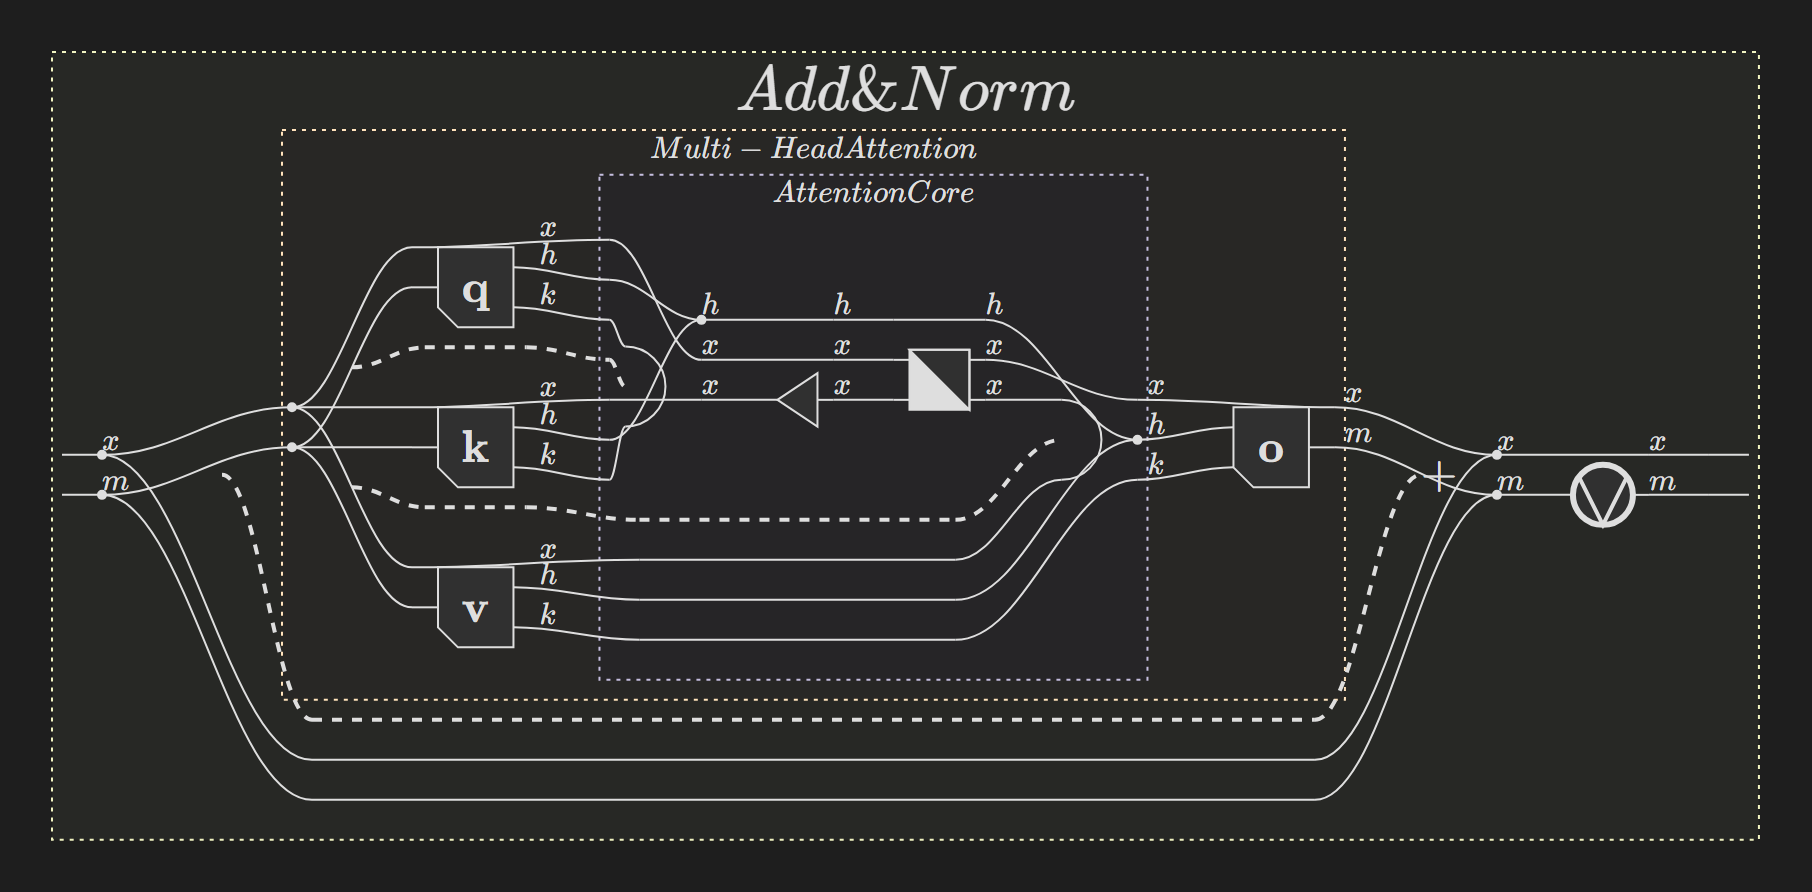

In [4]:
def residual[B: cat.Datatype, A: cat.Axis](
    target: cat.BroadcastedCategory[B, A],
) -> cat.Block[cat.Array[B, A], cat.BroadcastedCategory[B, A]]:
    return cat.Block.template(
        (0, 0) @ target @ ops.AdditionOp.template() @ ops.Normalize.template(),
        title='Add \\& Norm',
        fill_color='#F1F4C1')


residual_attention = residual(
    (0, 0, 0) @ cat.Block.template(
        attention_layer, title='Multi-Head Attention', fill_color='#FFE2BB'))

assert residual_attention.dom() == residual_attention.cod(), (
    'a residual sublayer returns the object it was given')
await notebook_diagrams.show_diagram(
    residual_attention,
    'The copy, the sublayer beside the wire that waits, the addition and the '
    'normalisation.',
    settings=DIAGRAMS)

## The feed-forward layer and the repeated stack

The feed-forward layer widens the residual to `d_ff`, applies an elementwise
function and narrows it back. Both sublayers return the object they were given,
so the layer built from them can be repeated. A `repetition` on a block states
that the body runs that many times, which the diagram draws as one box with the
count on it.

In [5]:
feed_forward = cat.Block.template(
    ops.Linear.template(1, ('d_ff',), 'in')
    @ ops.Elementwise.template()
    @ ops.Linear.template(('d_ff',), 1, 'out'),
    title='Feed Forward',
    fill_color='#C1E8F7')
transformer_layer = residual_attention @ residual(feed_forward)
layer_stack = cat.Block.template(
    transformer_layer,
    repetition=6,
    title='Transformer Layer',
    fill_color='#F3F3F4')

assert transformer_layer.dom() == transformer_layer.cod(), (
    'a repeated layer must return its own domain')
assert layer_stack.dom() == transformer_layer.dom(), (
    'repeating the layer does not change what it reads')

## The two ends of the model

The embedding reads a token index, an element of $\mathbb{N}_{\bar v}$, and
returns a vector of the residual width. The output head projects that width
onto the vocabulary and takes a softmax over it, so the model returns one
distribution per position.

The whole model, from token indices to a distribution over the vocabulary at each position.


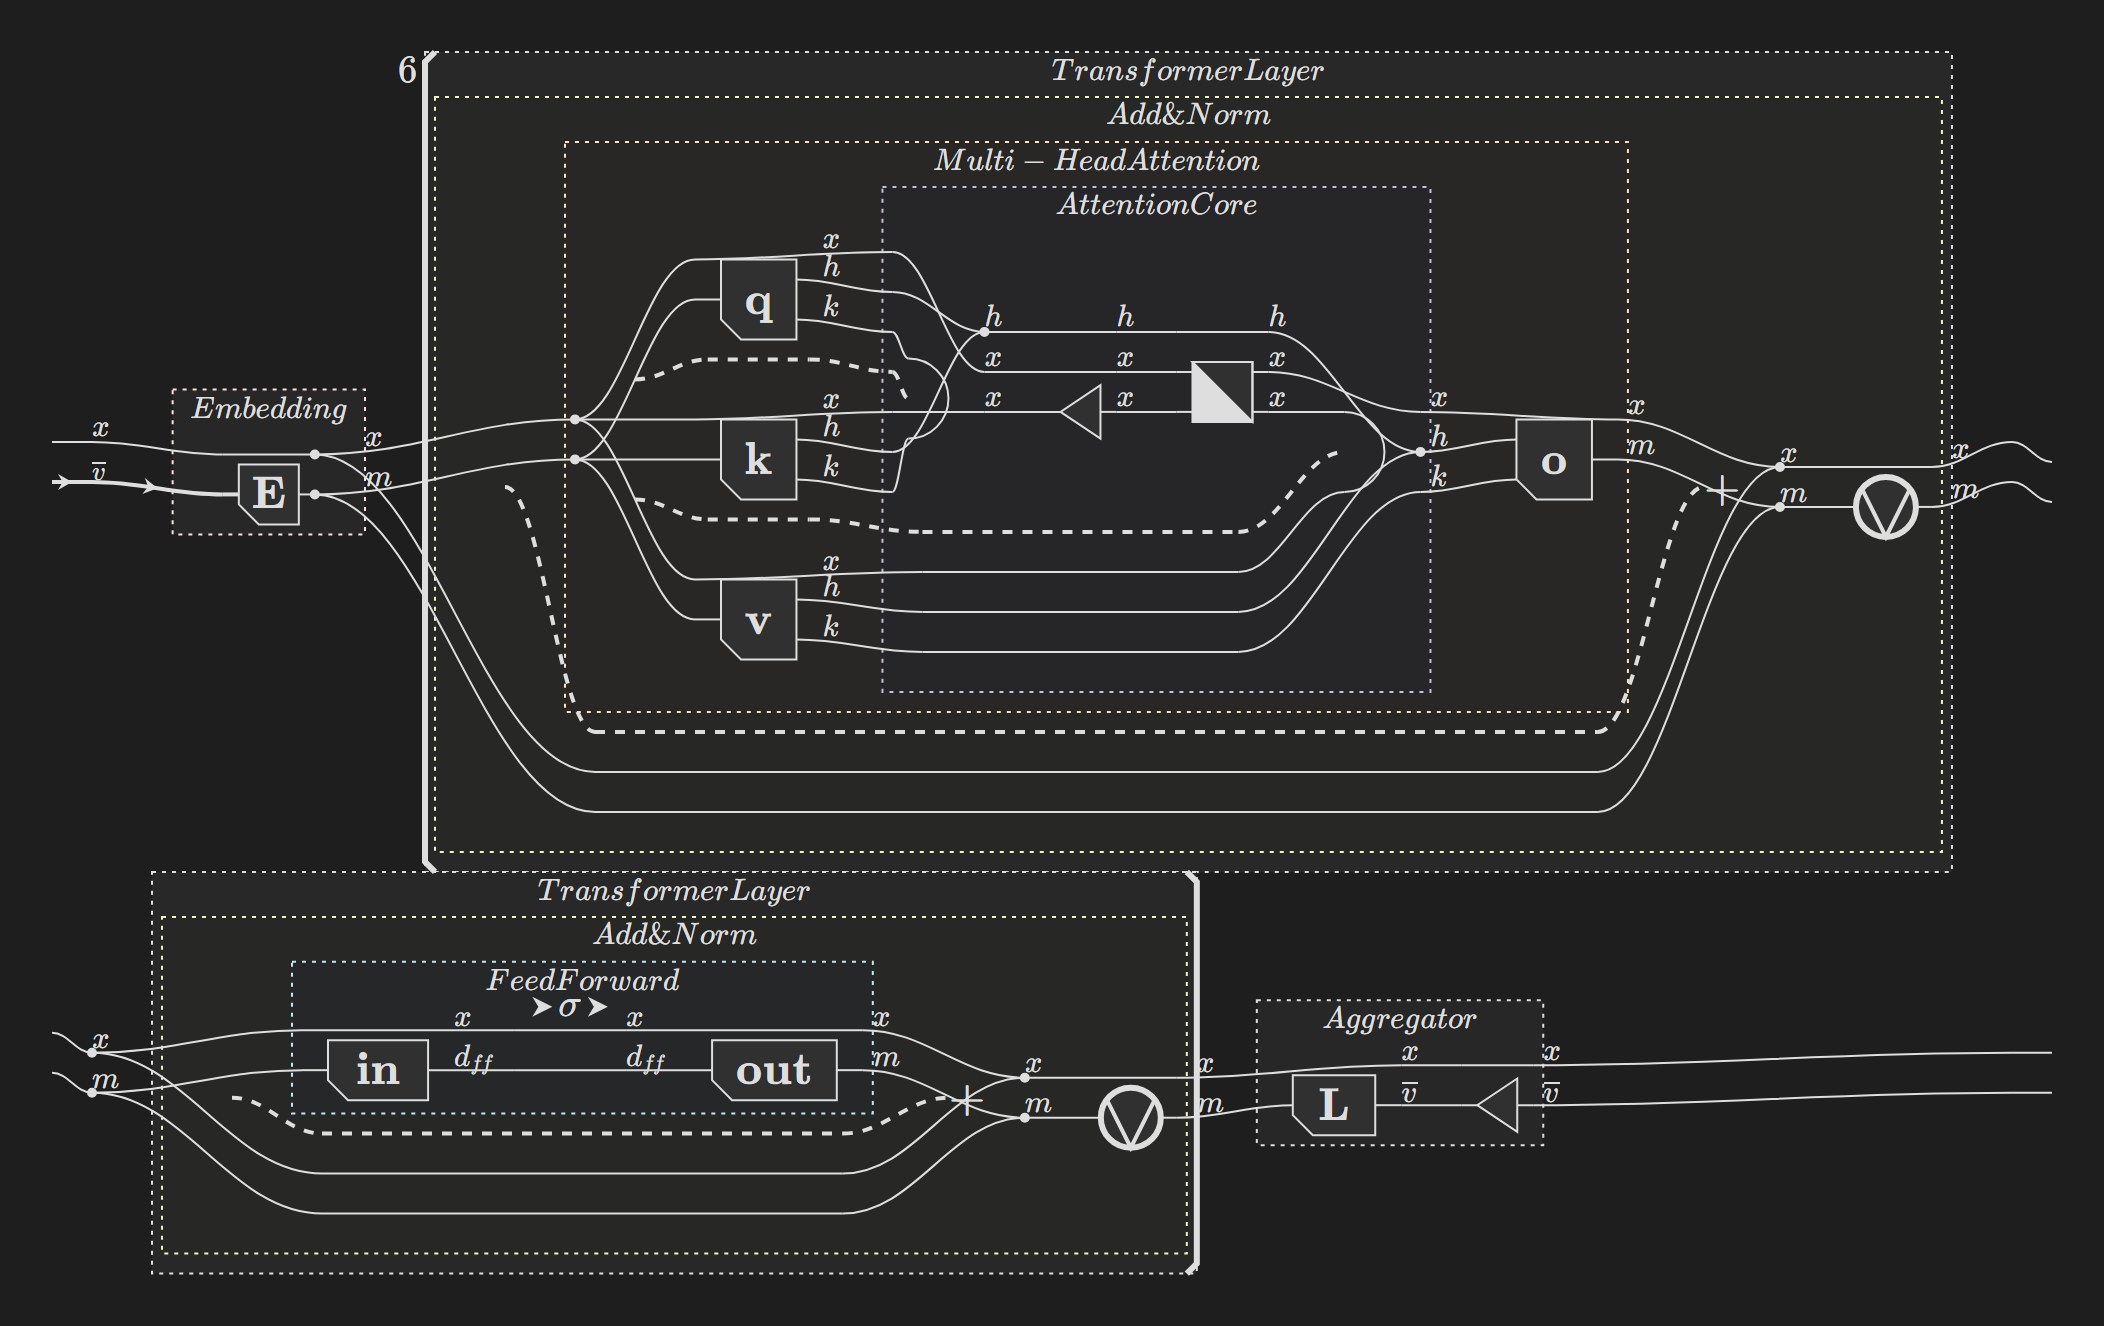

In [6]:
vocabulary = fd.DynamicName('v', settings=fd.DynamicNameSettings(overline=True))
embedding = cat.Block.template(
    ops.Embedding.template(vocabulary),
    title='Embedding',
    fill_color='#FCE0E1')
aggregator = cat.Block.template(
    ops.Linear.template(1, (vocabulary,)) @ ops.SoftMax.template(),
    title='Aggregator',
    fill_color='#DBDFEF')
transformer = embedding @ layer_stack @ aggregator

token_indices, = transformer.dom()
token_distribution, = transformer.cod()
assert isinstance(token_indices.datatype, cat.Natural), (
    'the model reads token indices, which are natural numbers')
assert isinstance(token_distribution.datatype, cat.Reals), (
    'the model returns real numbers')
await notebook_diagrams.show_diagram(
    transformer,
    'The whole model, from token indices to a distribution over the vocabulary '
    'at each position.',
    settings=DIAGRAMS)

## The expression as JSON

`term_json.TermJSONConverter` writes a term as JSON. Every term carrying a
unique identifier is written once into `uid_repository` and referred to by that
identifier wherever it occurs again, which is what keeps the shared subterms
shared. `export` writes the same payload to a file, and the diagram transport
sends it over the socket.

Reading the payload back needs the repository keyed by integers, because JSON
object keys are strings.

In [7]:
exported = json.loads(term_json.TermJSONConverter.export_to_json(transformer))
converter = term_json.TermJSONConverter(
    uid_repository={int(key): value
                    for key, value in exported['uid_repository'].items()})
restored = converter.reconstruct(exported['data'])

assert restored == transformer, 'the model survives the round trip through JSON'
print(f'{len(exported["uid_repository"])} distinct terms in the model')

24 distinct terms in the model


## Assigning the axis sizes

`NumericConfig` collects every free symbol of the expression and assigns an
integer to each name it is given. The sequence length stays free, because the
compiled module reads it from the input, and so does the epsilon of the
normalisation.

The sized model. Each wire carries the integer its axis was given.


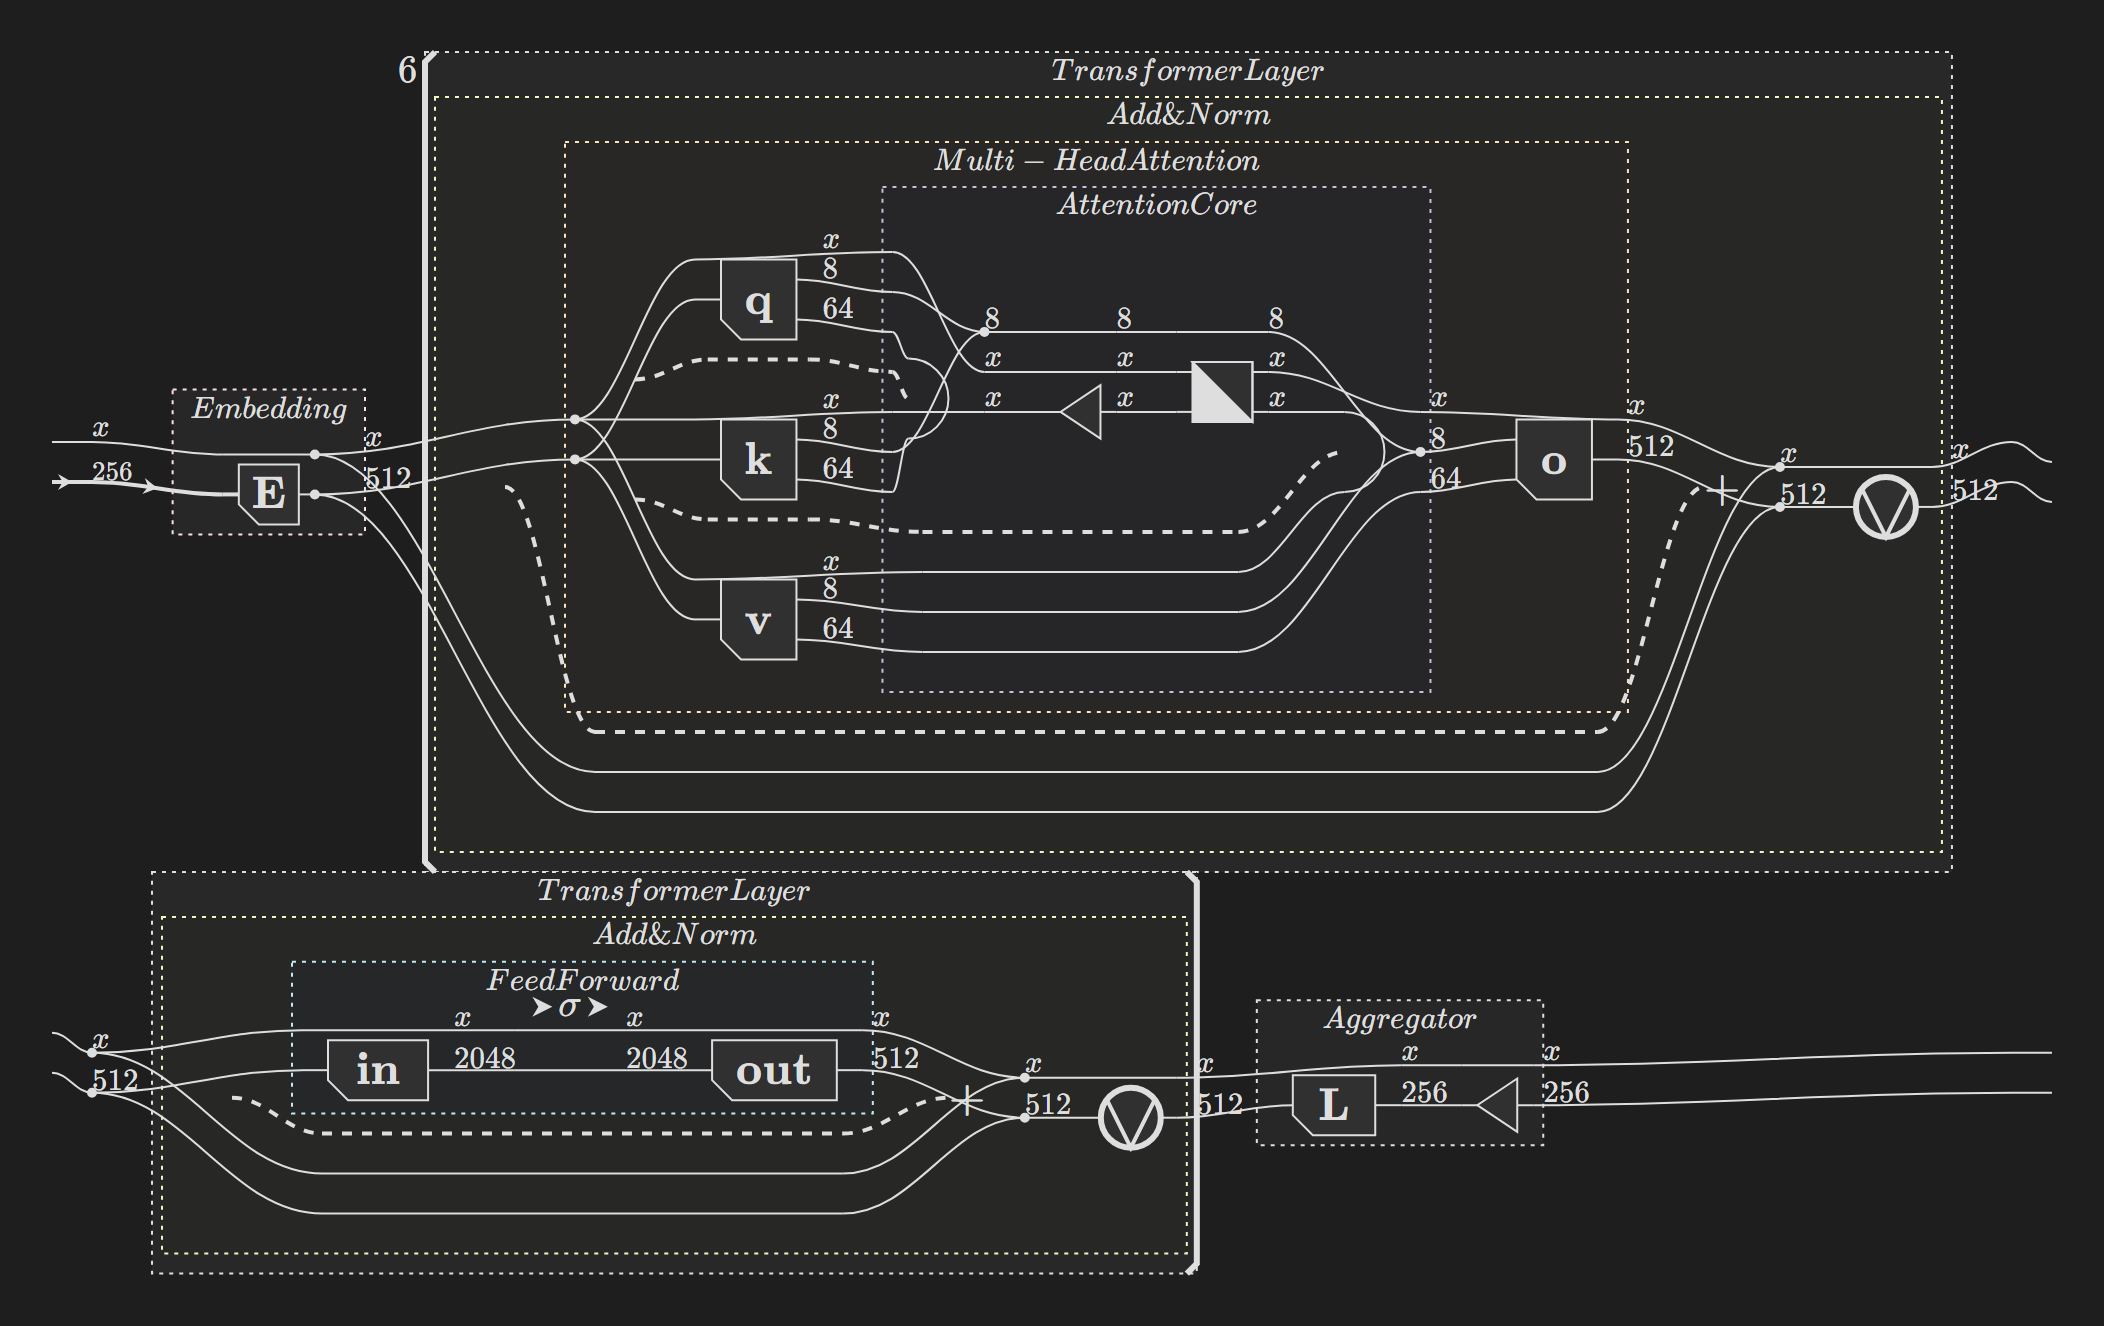

In [8]:
config = generate_config.NumericConfig.template(transformer)
config.assign_values(v=256, m=512, d=2048, k=64, h=8)
transformer_512 = config.apply_context(transformer)

remaining = generate_config.NumericConfig.template(transformer_512)
assert {term.uid._name.to_bodies() for term in remaining.terms} == {'x', '\\epsilon'}, (
    'the sequence length and the epsilon of the normalisation stay free')
await notebook_diagrams.show_diagram(
    transformer_512,
    'The sized model. Each wire carries the integer its axis was given.',
    settings=DIAGRAMS)

## Compiling to PyTorch

`torch_compile.ConstructedModule.construct` walks the sized expression and
builds an `nn.Module` for it, with a parameter for every weight. The module
reads a batch of token indices and returns one array per object of the
codomain. It needs `torch` and `einops`, and neither is listed in
`requirements.txt`.

In [9]:
module = torch_compile.ConstructedModule.construct(transformer_512)

BATCH, SEQUENCE_LENGTH, VOCABULARY = 3, 2, 256
indices = torch.randint(0, VOCABULARY, (BATCH, SEQUENCE_LENGTH))
distribution, = module(indices)

assert distribution.shape == (BATCH, SEQUENCE_LENGTH, VOCABULARY), (
    'the module returns one distribution over the vocabulary per token position')
print(f'{tuple(indices.shape)} token indices in, {tuple(distribution.shape)} out')

(3, 2) token indices in, (3, 2, 256) out
